<a href="https://colab.research.google.com/github/ys5591/Yunsu-Shin/blob/main/GLM_HMM_UPDATE(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# # FINAL DNMS GLM-HMM — WT-control reference model for Alex
#
# This Google Colab notebook implements the requested analysis:
#
# 1. Develop and cross-validate the model using **WT-control mice only**.
# 2. Do **not** use delay as a model predictor.
# 3. Choose the number of states from shuffled 80:20 held-out performance.
# 4. Refit the selected model on all WT-control trials and freeze it.
# 5. Apply that frozen model to WT-stress, Setd1a-control, and Setd1a-stress.
# 6. Plot state occupancy and state-specific performance by group and delay.
#
# The hidden-state labels describe fitted choice policies, not intentions or neural states.

In [ ]:
# Cell 1 — Install/import packages
import sys, subprocess, warnings, json, pickle, shutil, re
from pathlib import Path

def pip_install(*packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

pip_install("numpy", "pandas", "scipy", "scikit-learn", "seaborn", "openpyxl", "ipython")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy.special import expit, logsumexp
from sklearn.model_selection import GroupShuffleSplit
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")

In [ ]:
# ## Analysis decisions
#
# - Choice is modeled as left (`0`) versus right (`1`).
# - Observation predictors are DNMS correct side, previous choice, previous reward, and intercept.
# - **Delay is excluded from both observation and transition models.** It is used only after fitting.
# - Hidden-state transitions are a state-to-state Markov matrix. No genotype, stress, sex, delay,
#   or current-trial correctness enters the model.
# - The shuffled 80:20 split is performed on whole sessions, preserving each HMM sequence.
#   Individual trials are never shuffled across session boundaries. Set `SPLIT_UNIT="mouse"`
#   only for the stricter sensitivity analysis testing generalization to unseen mice.

In [ ]:
# Cell 2 — Settings and upload the one final analysis-input CSV
SEED = 20260902
K_LIST = [1, 2, 3, 4, 5]
N_SPLITS = 10
TEST_SIZE = 0.20
SPLIT_UNIT = "session"     # Alex-requested primary analysis; sensitivity option: "mouse"
N_INITS_CV = 5
N_INITS_FINAL = 10
MAX_EM_ITERS = 250
EM_TOL = 1e-5
L2_SIGMA = 10.0
MIN_STATE_OCCUPANCY = 0.03

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL")
else:
    ROOT = Path.cwd() / "DNMS_WT_reference"
OUT = ROOT / "results"
OUT.mkdir(parents=True, exist_ok=True)

if IN_COLAB:
    from google.colab import files
    print("Upload working_memory_glmhmm_alex_FINAL_INPUT.csv")
    uploaded = files.upload()
    csv_names = [n for n in uploaded if n.lower().endswith(".csv")]
    if not csv_names:
        raise ValueError("No CSV was uploaded.")
    DATA_PATH = Path("/content") / csv_names[0]
else:
    candidates = (list(Path.cwd().glob("*FINAL_INPUT*.csv")) +
                  list(Path.cwd().glob("working_memory*.csv")) +
                  list(Path.cwd().glob("*DNMS*.csv")))
    if not candidates:
        raise FileNotFoundError("Put the long-format CSV in the working directory.")
    DATA_PATH = candidates[0]

print("Trial data:", DATA_PATH)

Mounted at /content/drive
Upload working_memory_glmhmm_alex_FINAL_INPUT.csv


Saving working_memory_glmhmm_alex_FINAL_INPUT (1).csv to working_memory_glmhmm_alex_FINAL_INPUT (1) (1).csv
Trial data: /content/working_memory_glmhmm_alex_FINAL_INPUT (1) (1).csv


In [ ]:
# Cell 3 — Load and verify embedded mouse metadata
raw = pd.read_csv(DATA_PATH)
raw.columns = [str(c).strip() for c in raw.columns]

ALIASES = {
    "mouse_id": ["mouse_id", "mouse", "Mouse", "animal_id", "Animal"],
    "session_id": ["session_id", "session", "Session"],
    "trial_in_session": ["trial_in_session", "trial", "Trial", "trial_number"],
    "sample_side": ["sample_side", "sample", "Sample Side"],
    "choice": ["choice", "Choice", "choice_side"],
    "delay_s": ["delay_s", "delay_s_posthoc_only", "delay", "Delay"],
    "genotype": ["genotype", "Genotype", "geno"],
    "stress": ["stress", "Stress", "condition", "Condition"],
}

def standardize_columns(frame):
    frame = frame.copy()
    rename = {}
    for target, choices in ALIASES.items():
        if target in frame.columns:
            continue
        hit = next((c for c in choices if c in frame.columns), None)
        if hit is not None:
            rename[hit] = target
    return frame.rename(columns=rename)

df = standardize_columns(raw)
needed = ["mouse_id", "session_id", "trial_in_session", "sample_side", "choice", "delay_s"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Available: {list(df.columns)}")

# The final input already contains genotype/stress. The fallback upload below is retained only
# to give a clear error-recovery path if an older trial CSV is uploaded accidentally.
if "genotype" not in df.columns or "stress" not in df.columns:
    if not IN_COLAB:
        raise ValueError("genotype/stress missing. Add them or run in Colab and upload mouse metadata.")
    print("Upload the COMPLETED mouse_metadata_REQUIRED.csv containing mouse_id, genotype, and stress.")
    meta_upload = files.upload()
    meta_names = [n for n in meta_upload if n.lower().endswith(".csv")]
    if not meta_names:
        raise ValueError("Metadata CSV was not uploaded.")
    metadata = standardize_columns(pd.read_csv(Path("/content") / meta_names[0]))
    req_meta = ["mouse_id", "genotype", "stress"]
    if any(c not in metadata.columns for c in req_meta):
        raise ValueError(f"Metadata must contain {req_meta}.")
    metadata = metadata[req_meta].drop_duplicates("mouse_id")
    metadata["mouse_id"] = metadata["mouse_id"].astype(str).str.strip()
    df["mouse_id"] = df["mouse_id"].astype(str).str.strip()
    df = df.merge(metadata, on="mouse_id", how="left", validate="many_to_one")

df["mouse_id"] = df["mouse_id"].astype(str).str.strip()
df["session_id"] = df["session_id"].astype(str).str.strip()
df["trial_in_session"] = pd.to_numeric(df["trial_in_session"], errors="raise")
df["delay_s"] = pd.to_numeric(df["delay_s"], errors="raise")
df["sample_side"] = df["sample_side"].astype(str).str.lower().str.strip()
df["choice"] = df["choice"].astype(str).str.lower().str.strip()

def norm_genotype(x):
    s = str(x).lower().replace(" ", "").replace("−", "-")
    if s in {"wt", "wildtype", "wild-type", "+/+"}: return "WT"
    if "setd1a" in s or "+/-" in s or "+/−" in s: return "Setd1a+/-"
    return str(x).strip()

def norm_stress(x):
    s = str(x).lower().replace(" ", "").replace("_", "-")
    if s in {"control", "ctrl", "nostress", "no-stress", "unstressed"}: return "Control"
    if s in {"stress", "stressed", "restraint", "restraintstress"}: return "Stress"
    return str(x).strip()

df["genotype"] = df["genotype"].map(norm_genotype)
df["stress"] = df["stress"].map(norm_stress)

allowed_genotype = {"WT", "Setd1a+/-"}
allowed_stress = {"Control", "Stress"}
bad_genotype = sorted(set(df["genotype"].dropna()) - allowed_genotype)
bad_stress = sorted(set(df["stress"].dropna()) - allowed_stress)
if bad_genotype or bad_stress or df[["genotype", "stress"]].isna().any().any():
    raise ValueError(
        "Mouse metadata is incomplete or contains invalid labels. "
        f"Unexpected genotype={bad_genotype}; stress={bad_stress}. "
        "Use exactly WT/Setd1a+/- and Control/Stress."
    )

# Totals from the user-updated 45-mouse metadata. These checks catch an outdated input file.
mouse_meta_check = df[["mouse_id", "genotype", "stress"]].drop_duplicates("mouse_id")
geno_counts = mouse_meta_check["genotype"].value_counts().to_dict()
stress_counts = mouse_meta_check["stress"].value_counts().to_dict()
if geno_counts != {"WT": 23, "Setd1a+/-": 22}:
    raise ValueError(f"Genotype totals should be WT=23 and Setd1a+/-=22; found {geno_counts}.")
if stress_counts != {"Stress": 23, "Control": 22}:
    raise ValueError(f"Updated metadata totals should be Stress=23 and Control=22; found {stress_counts}.")

group_counts = mouse_meta_check.groupby(["genotype", "stress"]).size().to_dict()
expected_group_counts = {
    ("WT", "Control"): 12,
    ("WT", "Stress"): 11,
    ("Setd1a+/-", "Control"): 10,
    ("Setd1a+/-", "Stress"): 12,
}
if group_counts != expected_group_counts:
    raise ValueError(f"Updated four-group counts do not match: {group_counts}")

df["group"] = df["genotype"] + " | " + df["stress"]

valid_side = {"left", "right"}
for c in ["sample_side", "choice"]:
    if not df[c].isin(valid_side).all():
        display(df.loc[~df[c].isin(valid_side), [c]].drop_duplicates())
        raise ValueError(f"{c} must contain only left/right.")
df = df.sort_values(["mouse_id", "session_id", "trial_in_session"]).reset_index(drop=True)
df.to_csv(OUT/"analysis_input_with_verified_mouse_metadata.csv", index=False)
display(df.groupby(["genotype", "stress"])["mouse_id"].nunique().rename("n_mice"))
print(f"{df.mouse_id.nunique()} mice | {df.session_id.nunique()} sessions | {len(df)} trials")

genotype   stress 
Setd1a+/-  Control    10
           Stress     12
WT         Control    12
           Stress     11
Name: n_mice, dtype: int64

45 mice | 405 sessions | 12150 trials


In [ ]:
# Cell 4 — Verify and use the revised NO-DELAY model columns
df["choice_right"] = (df["choice"] == "right").astype(int)
df["sample_signed"] = np.where(df["sample_side"].eq("right"), 1.0, -1.0)
df["choice_signed"] = np.where(df["choice"].eq("right"), 1.0, -1.0)
df["correct_side_signed"] = -df["sample_signed"]
df["trial_correct"] = (df["choice_signed"] == df["correct_side_signed"]).astype(int)
df["reward_signed"] = np.where(df["trial_correct"].eq(1), 1.0, -1.0)

g = df.groupby("session_id", sort=False)
df["prev_choice_signed"] = g["choice_signed"].shift(1).fillna(0.0)
df["prev_reward_signed"] = g["reward_signed"].shift(1).fillna(0.0)
df["intercept"] = 1.0

prepared_columns = [
    "model_x_correct_side_signed", "model_x_prev_choice_signed",
    "model_x_prev_reward_signed", "model_x_intercept"
]
derived_columns = ["correct_side_signed", "prev_choice_signed", "prev_reward_signed", "intercept"]

if all(c in df.columns for c in prepared_columns):
    # Cross-check the prepared values against independently derived values.
    for prepared, derived in zip(prepared_columns, derived_columns):
        if not np.allclose(pd.to_numeric(df[prepared], errors="raise"), df[derived]):
            raise ValueError(f"Prepared predictor {prepared} does not match derived {derived}.")
    PREDICTORS = prepared_columns
    if "model_output_choice_right" in df.columns:
        if not np.array_equal(df["model_output_choice_right"].astype(int), df["choice_right"]):
            raise ValueError("model_output_choice_right disagrees with choice_right.")
else:
    warnings.warn("Prepared model_x columns not found; using verified derived no-delay columns.")
    PREDICTORS = derived_columns

assert not any("delay" in x.lower() for x in PREDICTORS)

X = df[PREDICTORS].to_numpy(float)
y = df["model_output_choice_right"].to_numpy(int) if "model_output_choice_right" in df else df["choice_right"].to_numpy(int)

reference_mask = df["genotype"].eq("WT") & df["stress"].eq("Control")
if reference_mask.sum() == 0:
    raise ValueError("No WT-control trials were found after label normalization.")

print("Model predictors (delay intentionally absent):", PREDICTORS)
print("WT-control reference:", df.loc[reference_mask, "mouse_id"].nunique(), "mice,",
      df.loc[reference_mask, "session_id"].nunique(), "sessions,", int(reference_mask.sum()), "trials")

Model predictors (delay intentionally absent): ['model_x_correct_side_signed', 'model_x_prev_choice_signed', 'model_x_prev_reward_signed', 'model_x_intercept']
WT-control reference: 12 mice, 108 sessions, 3240 trials


In [ ]:
# Cell 5 — Standalone GLM-HMM implementation (Bernoulli observations, fixed Markov transitions)
def session_arrays(indices):
    sub = df.iloc[np.asarray(indices)].copy()
    ans = []
    for _, s in sub.groupby("session_id", sort=False):
        ii = s.index.to_numpy()
        ans.append((X[ii], y[ii], ii))
    return ans

def log_emissions(Xs, ys, W):
    logits = Xs @ W.T
    # log P(y|state), stable Bernoulli form
    return ys[:, None] * (-np.logaddexp(0, -logits)) + (1-ys[:, None]) * (-np.logaddexp(0, logits))

def forward_backward(logB, pi, A):
    T, K = logB.shape
    logA = np.log(np.clip(A, 1e-300, 1))
    logpi = np.log(np.clip(pi, 1e-300, 1))
    alpha = np.empty((T, K)); beta = np.zeros((T, K))
    alpha[0] = logpi + logB[0]
    for t in range(1, T):
        alpha[t] = logB[t] + logsumexp(alpha[t-1][:, None] + logA, axis=0)
    ll = float(logsumexp(alpha[-1]))
    for t in range(T-2, -1, -1):
        beta[t] = logsumexp(logA + logB[t+1][None, :] + beta[t+1][None, :], axis=1)
    gamma = np.exp(alpha + beta - ll)
    gamma /= gamma.sum(axis=1, keepdims=True)
    xis = np.empty((max(T-1, 0), K, K))
    for t in range(T-1):
        z = alpha[t][:, None] + logA + logB[t+1][None, :] + beta[t+1][None, :] - ll
        xis[t] = np.exp(z)
        xis[t] /= xis[t].sum()
    return ll, gamma, xis

def weighted_logistic_fit(Xcat, ycat, weights, w0):
    def objective(w):
        z = Xcat @ w
        nll = np.sum(weights * (np.logaddexp(0, z) - ycat*z))
        nll += 0.5*np.sum((w/L2_SIGMA)**2)
        grad = Xcat.T @ (weights*(expit(z)-ycat)) + w/(L2_SIGMA**2)
        return nll, grad
    return minimize(lambda w: objective(w)[0], w0, jac=lambda w: objective(w)[1],
                    method="L-BFGS-B", options={"maxiter":1000, "ftol":1e-10}).x

def fit_glmhmm(sequences, K, seed):
    local = np.random.default_rng(seed)
    M = sequences[0][0].shape[1]
    Xcat = np.vstack([s[0] for s in sequences]); ycat = np.concatenate([s[1] for s in sequences])
    base = weighted_logistic_fit(Xcat, ycat, np.ones(len(ycat)), np.zeros(M))
    W = base[None, :] + local.normal(0, 0.35, size=(K, M))
    if K == 1:
        W[0] = base
    A = np.full((K, K), 0.15/max(K-1, 1))
    np.fill_diagonal(A, 0.85 if K > 1 else 1.0)
    A /= A.sum(axis=1, keepdims=True)
    pi = np.ones(K)/K
    trace = []

    for iteration in range(MAX_EM_ITERS):
        gammas, xi_sum, pi_sum, ll = [], np.zeros((K,K)), np.zeros(K), 0.0
        for Xs, ys, _ in sequences:
            lli, gamma, xis = forward_backward(log_emissions(Xs, ys, W), pi, A)
            ll += lli; gammas.append(gamma); pi_sum += gamma[0]
            if len(xis): xi_sum += xis.sum(axis=0)
        trace.append(ll)
        pi = (pi_sum + 1e-2); pi /= pi.sum()
        A = xi_sum + 1.1  # mild Dirichlet smoothing
        A /= A.sum(axis=1, keepdims=True)
        gamma_cat = np.vstack(gammas)
        for k in range(K):
            W[k] = weighted_logistic_fit(Xcat, ycat, gamma_cat[:,k], W[k])
        if len(trace) > 2 and abs(trace[-1]-trace[-2]) < EM_TOL*(1+abs(trace[-2])):
            break
    return {"K":K, "W":W, "A":A, "pi":pi, "trace":trace, "train_ll":trace[-1]}

def score_model(model, sequences, return_posteriors=False):
    total_ll, n = 0.0, 0
    posts = []
    for Xs, ys, idx in sequences:
        ll, gamma, _ = forward_backward(log_emissions(Xs, ys, model["W"]), model["pi"], model["A"])
        total_ll += ll; n += len(ys)
        if return_posteriors: posts.append((idx, gamma))
    return total_ll, n, posts

def best_restart(sequences, K, n_inits, seed_base):
    fits = [fit_glmhmm(sequences, K, seed_base + i) for i in range(n_inits)]
    return max(fits, key=lambda m: m["train_ll"])

In [ ]:
# Cell 6 — WT-control shuffled 80:20 cross-validation
ref = df.loc[reference_mask]
ref_idx = ref.index.to_numpy()
split_groups = ref["mouse_id"].to_numpy() if SPLIT_UNIT == "mouse" else ref["session_id"].to_numpy()
splitter = GroupShuffleSplit(n_splits=N_SPLITS, test_size=TEST_SIZE, random_state=SEED)

CV_CHECKPOINT = OUT / "WTcontrol_80_20_cv_checkpoint.csv"
if CV_CHECKPOINT.exists():
    previous_cv = pd.read_csv(CV_CHECKPOINT)
    cv_rows = previous_cv.to_dict("records")
    completed = set(zip(previous_cv["split"].astype(int), previous_cv["K"].astype(int)))
    print(f"Resuming from {len(completed)} completed split/K fits")
else:
    cv_rows = []
    completed = set()

for split_id, (tr_local, te_local) in enumerate(splitter.split(ref_idx, groups=split_groups)):
    train_idx, test_idx = ref_idx[tr_local], ref_idx[te_local]
    train_seq, test_seq = session_arrays(train_idx), session_arrays(test_idx)
    train_rate = float(y[train_idx].mean())
    for K in K_LIST:
        if (split_id, K) in completed:
            print(f"skip completed split {split_id+1}/{N_SPLITS}, K={K}")
            continue
        print(f"split {split_id+1}/{N_SPLITS}, K={K}")
        model = best_restart(train_seq, K, N_INITS_CV, SEED + split_id*1000 + K*100)
        train_ll, n_train, _ = score_model(model, train_seq)
        ll, n_test, _ = score_model(model, test_seq)
        y_test = y[test_idx]
        p0 = np.clip(train_rate, 1e-9, 1-1e-9)
        y_train = y[train_idx]
        train_ll0 = float(np.sum(y_train*np.log(p0) + (1-y_train)*np.log(1-p0)))
        ll0 = float(np.sum(y_test*np.log(p0) + (1-y_test)*np.log(1-p0)))
        cv_rows.append({"split":split_id, "K":K,
                        "train_ll":train_ll, "n_train":n_train,
                        "train_ll_per_trial":train_ll/n_train,
                        "train_bits_per_trial_over_baseline":(train_ll-train_ll0)/(n_train*np.log(2)),
                        "test_ll":ll, "n_test":n_test,
                        "test_ll_per_trial":ll/n_test,
                        "bits_per_trial_over_baseline":(ll-ll0)/(n_test*np.log(2))})
        pd.DataFrame(cv_rows).to_csv(CV_CHECKPOINT, index=False)

cv = pd.DataFrame(cv_rows)
cv.to_csv(OUT/"WTcontrol_80_20_cv_all_K.csv", index=False)
display(cv.groupby("K").agg(mean_bits=("bits_per_trial_over_baseline","mean"),
                             sd_bits=("bits_per_trial_over_baseline","std"),
                             mean_ll_trial=("test_ll_per_trial","mean")))

Resuming from 26 completed split/K fits
skip completed split 1/10, K=1
skip completed split 1/10, K=2
skip completed split 1/10, K=3
skip completed split 1/10, K=4
skip completed split 1/10, K=5
skip completed split 2/10, K=1
skip completed split 2/10, K=2
skip completed split 2/10, K=3
skip completed split 2/10, K=4
skip completed split 2/10, K=5
skip completed split 3/10, K=1
skip completed split 3/10, K=2
skip completed split 3/10, K=3
skip completed split 3/10, K=4
skip completed split 3/10, K=5
skip completed split 4/10, K=1
skip completed split 4/10, K=2
skip completed split 4/10, K=3
skip completed split 4/10, K=4
skip completed split 4/10, K=5
skip completed split 5/10, K=1
skip completed split 5/10, K=2
skip completed split 5/10, K=3
skip completed split 5/10, K=4
skip completed split 5/10, K=5
skip completed split 6/10, K=1
split 6/10, K=2
split 6/10, K=3
split 6/10, K=4
split 6/10, K=5
split 7/10, K=1
split 7/10, K=2
split 7/10, K=3
split 7/10, K=4
split 7/10, K=5
split 8/10

,mean_bits,sd_bits,mean_ll_trial
K,,,
1,0.125771,0.021835,-0.605594
2,0.149710,0.027986,-0.589001
3,0.159238,0.029186,-0.582397
4,0.156046,0.029628,-0.584609
5,0.152943,0.029288,-0.586759


Numerically best K: 3
One-SE eligible K values: [3, 4, 5]
Selected parsimonious K: 3


,K,mean_cv_bits,within_one_SE,min_soft_occupancy,occupancy_pass,selected
0,3,0.159238,True,0.257467,True,True
1,4,0.156046,True,0.105033,True,False
2,5,0.152943,True,0.103342,True,False


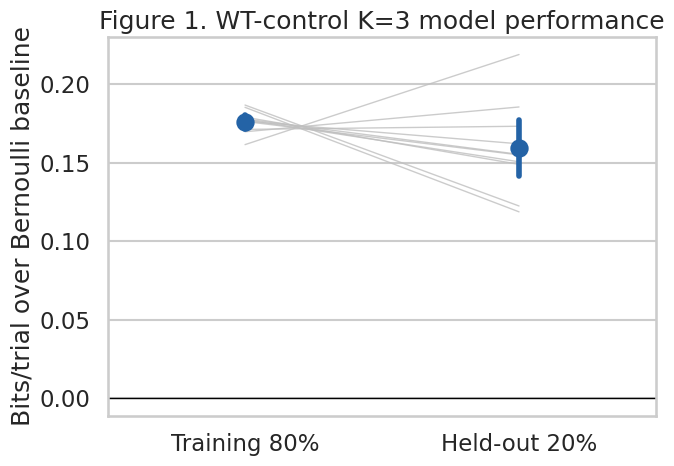

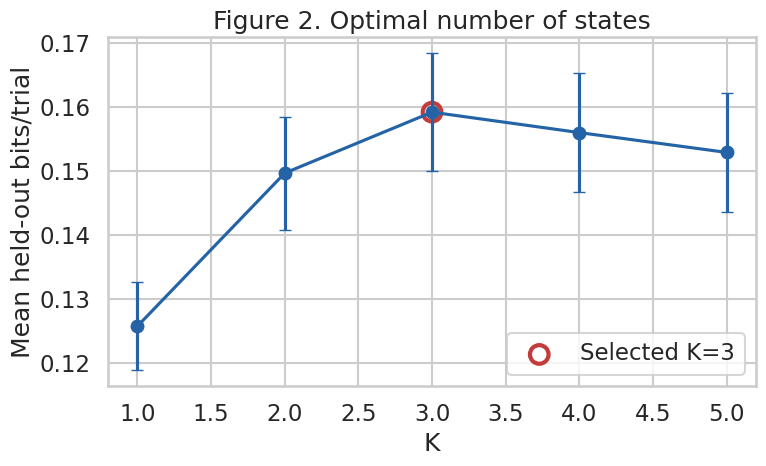

In [ ]:
# Cell 7 — Figures 1–2: selected-model performance and optimal K
mean_perf = cv.groupby("K")["bits_per_trial_over_baseline"].mean()
se_perf = cv.groupby("K")["bits_per_trial_over_baseline"].sem().fillna(0.0)
best_numeric = int(mean_perf.idxmax())
threshold = mean_perf.loc[best_numeric] - se_perf.loc[best_numeric]  # one-SE rule
eligible = [int(k) for k in mean_perf.index if mean_perf.loc[k] >= threshold]

# Fit eligible models to all reference trials and reject collapsed states.
ref_seq = session_arrays(ref_idx)
candidate_models, structure_rows = {}, []
for K in eligible:
    model = best_restart(ref_seq, K, N_INITS_FINAL, SEED + 50000 + K*100)
    _, _, posts = score_model(model, ref_seq, True)
    gamma = np.vstack([p for _,p in posts])
    min_occ = float(gamma.mean(axis=0).min())
    candidate_models[K] = model
    structure_rows.append({"K":K, "mean_cv_bits":mean_perf.loc[K], "within_one_SE":True,
                           "min_soft_occupancy":min_occ, "occupancy_pass":min_occ>=MIN_STATE_OCCUPANCY})

structure = pd.DataFrame(structure_rows)
passing = structure.loc[structure["occupancy_pass"], "K"].tolist()
OPTIMAL_K = int(min(passing)) if passing else int(min(eligible))
final_model = candidate_models[OPTIMAL_K]
structure["selected"] = structure["K"].eq(OPTIMAL_K)
structure.to_csv(OUT/"figure2_optimal_state_selection.csv", index=False)

print("Numerically best K:", best_numeric)
print("One-SE eligible K values:", eligible)
print("Selected parsimonious K:", OPTIMAL_K)
display(structure)

# Figure 1: train versus held-out performance for the selected WT-control model.
selected_cv = cv.loc[cv["K"].eq(OPTIMAL_K)].copy()
performance_long = pd.concat([
    selected_cv[["split", "train_bits_per_trial_over_baseline"]]
      .rename(columns={"train_bits_per_trial_over_baseline":"bits_per_trial"})
      .assign(dataset="Training 80%"),
    selected_cv[["split", "bits_per_trial_over_baseline"]]
      .rename(columns={"bits_per_trial_over_baseline":"bits_per_trial"})
      .assign(dataset="Held-out 20%"),
], ignore_index=True)
performance_long.to_csv(OUT/"figure1_selected_K_train_test_performance.csv", index=False)

fig, ax = plt.subplots(figsize=(7,5))
for split_id, sub in performance_long.groupby("split"):
    sub = sub.set_index("dataset").reindex(["Training 80%", "Held-out 20%"])
    ax.plot([0,1], sub["bits_per_trial"], color="0.75", lw=1, alpha=.8)
sns.pointplot(data=performance_long, x="dataset", y="bits_per_trial", errorbar=("ci",95),
              color="#2463A6", markers="o", linestyles="none", ax=ax)
ax.axhline(0, color="black", lw=1)
ax.set(title=f"Figure 1. WT-control K={OPTIMAL_K} model performance",
       xlabel="", ylabel="Bits/trial over Bernoulli baseline")
fig.tight_layout(); fig.savefig(OUT/"Figure_1_WTcontrol_selected_model_performance.png", dpi=300); plt.show()

# Figure 2: held-out performance across K, with the selected K highlighted.
fig, ax = plt.subplots(figsize=(8,5))
summary = cv.groupby("K")["bits_per_trial_over_baseline"].agg(["mean","sem"]).reset_index()
ax.errorbar(summary["K"], summary["mean"], yerr=summary["sem"].fillna(0.0),
            marker="o", capsize=4, color="#2463A6")
ax.scatter([OPTIMAL_K], [mean_perf.loc[OPTIMAL_K]], s=180, facecolors="none", edgecolors="#C43B3B", lw=3,
           label=f"Selected K={OPTIMAL_K}")
ax.set(title="Figure 2. Optimal number of states", xlabel="K", ylabel="Mean held-out bits/trial")
ax.legend(); fig.tight_layout(); fig.savefig(OUT/"Figure_2_optimal_number_of_states.png", dpi=300); plt.show()

In [ ]:
# The one-standard-error rule selects the smallest model statistically close to the best mean
# performance. The additional occupancy check prevents selection of a model containing an almost
# unused state. Report both the numerically best K and the parsimonious selected K.

,raw_state,state,rank_1,rank_2,model_x_correct_side_signed,model_x_prev_choice_signed,model_x_prev_reward_signed,model_x_intercept
0,0,S1: side-bias (left),side-bias,DNMS-rule,0.666174,-0.347774,-0.303270,-1.342213
1,1,S2: side-bias (right),side-bias,DNMS-rule,0.655690,0.022718,0.115263,0.792729
2,2,S3: DNMS-rule (rule-following),DNMS-rule,side-bias,1.577949,-0.132092,-0.128285,-0.163366


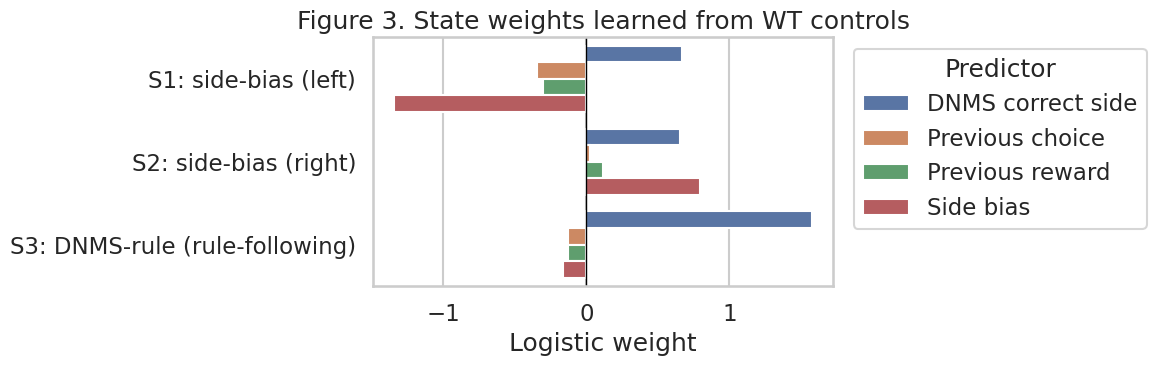

In [ ]:
# Cell 8 — Figure 3: rank-based state descriptions from WT-control weights
W = final_model["W"]

def build_rank_labels(W, predictors):
    # Both prepared and fallback predictors use this fixed +/-1 coding order.
    idx = {"correct_side":0, "prev_choice":1, "prev_reward":2, "intercept":3}
    rows = []
    for k, w in enumerate(W):
        components = {
            "DNMS-rule": abs(w[idx["correct_side"]]),
            "previous-choice": abs(w[idx["prev_choice"]]),
            "reward-history": abs(w[idx["prev_reward"]]),
            "side-bias": abs(w[idx["intercept"]]),
        }
        ranked = sorted(components, key=components.get, reverse=True)
        direction = ""
        primary = ranked[0]
        if primary == "side-bias": direction = "right" if w[idx["intercept"]] > 0 else "left"
        elif primary == "previous-choice": direction = "stay" if w[idx["prev_choice"]] > 0 else "switch"
        elif primary == "reward-history": direction = "positive" if w[idx["prev_reward"]] > 0 else "negative"
        elif primary == "DNMS-rule": direction = "rule-following" if w[idx["correct_side"]] > 0 else "anti-rule"
        label = f"S{k+1}: {primary} ({direction})"
        rows.append({"raw_state":k, "state":label, "rank_1":ranked[0], "rank_2":ranked[1],
                     **{p:float(w[i]) for i,p in enumerate(predictors)}})
    return pd.DataFrame(rows)

state_table = build_rank_labels(W, PREDICTORS)
state_labels = dict(zip(state_table.raw_state, state_table.state))
state_table.to_csv(OUT/"figure3_state_weight_ranks.csv", index=False)
display(state_table)

wlong = state_table.melt(id_vars=["raw_state","state","rank_1","rank_2"], value_vars=PREDICTORS,
                         var_name="predictor", value_name="weight")
wlong["predictor"] = wlong["predictor"].map(dict(zip(PREDICTORS, [
    "DNMS correct side", "Previous choice", "Previous reward", "Side bias"
])))
fig, ax = plt.subplots(figsize=(12, max(4, 0.8*OPTIMAL_K)))
sns.barplot(data=wlong, y="state", x="weight", hue="predictor", ax=ax)
ax.axvline(0, color="black", lw=1)
ax.set(title="Figure 3. State weights learned from WT controls", xlabel="Logistic weight", ylabel="")
ax.legend(title="Predictor", bbox_to_anchor=(1.02,1), loc="upper left")
fig.tight_layout(); fig.savefig(OUT/"Figure_3_state_weights_and_ranks.png", dpi=300, bbox_inches="tight"); plt.show()

In [ ]:
# Cell 9 — Freeze model and infer states for all four groups (no refitting)
all_seq = session_arrays(df.index.to_numpy())
_, _, all_posts = score_model(final_model, all_seq, True)
posterior = np.full((len(df), OPTIMAL_K), np.nan)
for idx, gamma in all_posts:
    posterior[idx] = gamma
if np.isnan(posterior).any():
    raise RuntimeError("Some trials were not assigned posterior probabilities.")

df["state_raw"] = posterior.argmax(axis=1)
df["state"] = df["state_raw"].map(state_labels)
df["state_probability"] = posterior.max(axis=1)

with open(OUT/"frozen_WTcontrol_reference_model.pkl", "wb") as f:
    pickle.dump({"model":final_model, "predictors":PREDICTORS, "state_table":state_table,
                 "optimal_K":OPTIMAL_K, "settings":{
                     "split_unit":SPLIT_UNIT, "n_splits":N_SPLITS, "test_size":TEST_SIZE,
                     "seed":SEED, "delay_used_as_predictor":False}}, f)
df.to_csv(OUT/"all_trials_with_frozen_reference_states.csv", index=False)

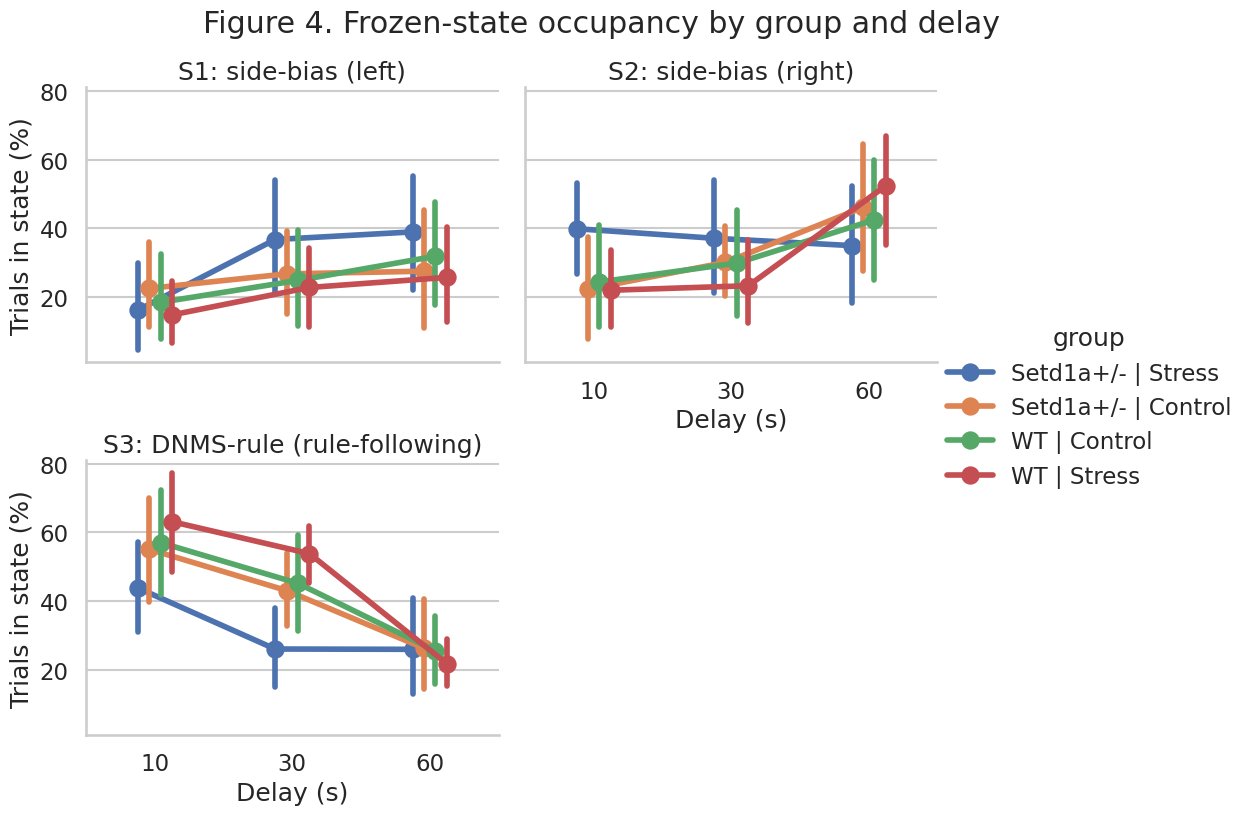

In [ ]:
# Cell 10 — Figure 4: percent of trials in each state by delay and group
# First summarize within mouse × delay so each mouse contributes equally.
counts = (df.groupby(["mouse_id","group","delay_s","state"], observed=True).size()
            .rename("n_state").reset_index())
totals = (df.groupby(["mouse_id","group","delay_s"], observed=True).size()
            .rename("n_total").reset_index())
state_frame = pd.DataFrame({"state": list(state_labels.values())})
grid = (totals.assign(_key=1)
              .merge(state_frame.assign(_key=1), on="_key")
              .drop(columns="_key"))
occupancy_mouse = grid.merge(
    counts, on=["mouse_id","group","delay_s","state"], how="left"
)
occupancy_mouse["n_state"] = occupancy_mouse["n_state"].fillna(0).astype(int)
occupancy_mouse["percent_trials"] = 100*occupancy_mouse["n_state"]/occupancy_mouse["n_total"]
occupancy_mouse.to_csv(OUT/"figure4_mouse_level_state_occupancy.csv", index=False)

g = sns.catplot(data=occupancy_mouse, x="delay_s", y="percent_trials", hue="group", col="state",
                kind="point", errorbar=("ci",95), dodge=0.25, col_wrap=2, height=4, aspect=1.25,
                markers="o", linestyles="-")
g.set_axis_labels("Delay (s)", "Trials in state (%)")
g.set_titles("{col_name}")
g.figure.suptitle("Figure 4. Frozen-state occupancy by group and delay", y=1.03)
g.figure.savefig(OUT/"Figure_4_state_occupancy_group_by_delay.png", dpi=300, bbox_inches="tight")
plt.show()

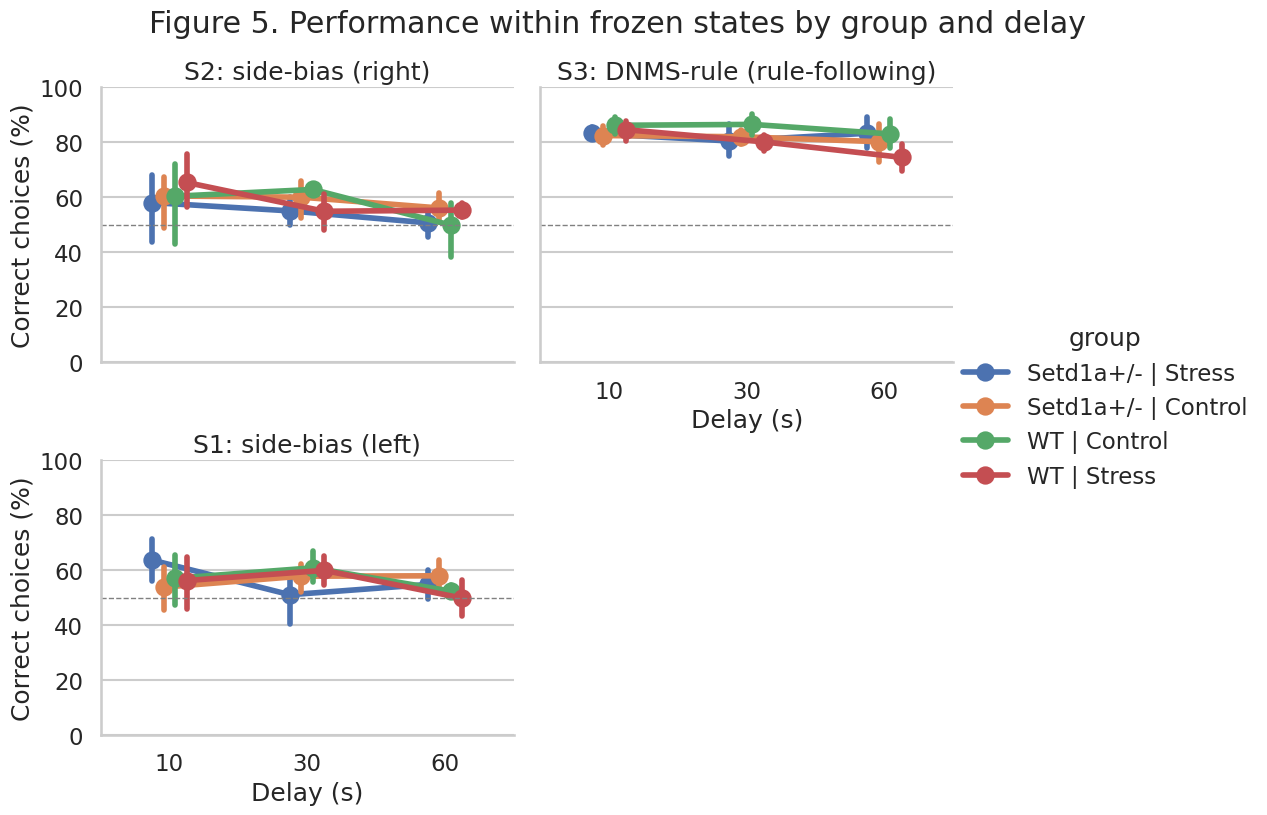

In [ ]:
# Cell 11 — Figure 5: performance within state by delay and group
performance_mouse = (df.groupby(["mouse_id","group","delay_s","state"], observed=True)
                       .agg(n_trials=("trial_correct","size"), accuracy=("trial_correct","mean"))
                       .reset_index())
performance_mouse["accuracy_percent"] = 100*performance_mouse["accuracy"]
performance_mouse.to_csv(OUT/"figure5_mouse_level_state_accuracy.csv", index=False)

g = sns.catplot(data=performance_mouse, x="delay_s", y="accuracy_percent", hue="group", col="state",
                kind="point", errorbar=("ci",95), dodge=0.25, col_wrap=2, height=4, aspect=1.25,
                markers="o", linestyles="-")
for ax in g.axes.flat:
    ax.axhline(50, color="gray", ls="--", lw=1)
    ax.set_ylim(0,100)
g.set_axis_labels("Delay (s)", "Correct choices (%)")
g.set_titles("{col_name}")
g.figure.suptitle("Figure 5. Performance within frozen states by group and delay", y=1.03)
g.figure.savefig(OUT/"Figure_5_state_performance_group_by_delay.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Cell 12 — QC tables and ready-to-send output package
qc = {
    "n_mice": int(df.mouse_id.nunique()),
    "n_sessions": int(df.session_id.nunique()),
    "n_trials": int(len(df)),
    "wt_control_mice": int(df.loc[reference_mask,"mouse_id"].nunique()),
    "wt_control_trials": int(reference_mask.sum()),
    "predictors": PREDICTORS,
    "delay_used_as_predictor": False,
    "split_unit": SPLIT_UNIT,
    "optimal_K": OPTIMAL_K,
    "mean_max_posterior": float(df.state_probability.mean()),
}
with open(OUT/"analysis_QC.json", "w") as f:
    json.dump(qc, f, indent=2)

print(json.dumps(qc, indent=2))
display(df.groupby(["group","delay_s"])["mouse_id"].nunique().rename("n_mice"))
display(df.groupby("state").agg(n_trials=("state","size"),
                                 occupancy=("state","size"),
                                 accuracy=("trial_correct","mean"),
                                 mean_confidence=("state_probability","mean")))

archive = shutil.make_archive(str(ROOT/"DNMS_WTcontrol_reference_results"), "zip", OUT)
print("Created:", archive)
if IN_COLAB:
    files.download(archive)

{
  "n_mice": 45,
  "n_sessions": 405,
  "n_trials": 12150,
  "wt_control_mice": 12,
  "wt_control_trials": 3240,
  "predictors": [
    "model_x_correct_side_signed",
    "model_x_prev_choice_signed",
    "model_x_prev_reward_signed",
    "model_x_intercept"
  ],
  "delay_used_as_predictor": false,
  "split_unit": "session",
  "optimal_K": 3,
  "mean_max_posterior": 0.7499944230851897
}


group                delay_s
Setd1a+/- | Control  10         10
                     30         10
                     60         10
Setd1a+/- | Stress   10         12
                     30         12
                     60         12
WT | Control         10         12
                     30         12
                     60         12
WT | Stress          10         11
                     30         11
                     60         11
Name: n_mice, dtype: int64

,n_trials,occupancy,accuracy,mean_confidence
state,,,,
S1: side-bias (left),3127,3127,0.576591,0.755514
S2: side-bias (right),4111,4111,0.595962,0.781087
S3: DNMS-rule (rule-following),4912,4912,0.827972,0.720458


Created: /content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/DNMS_WTcontrol_reference_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ## What to report to Alex
#
# - Figure 1: training-versus-held-out performance for the selected WT-control model.
# - Figure 2: held-out WT-control prediction across K under shuffled 80:20 splits.
# - Figure 3: state weights and rank-based policy descriptions.
# - Figure 4: mouse-balanced percentage of trials in each frozen state, by group and delay.
# - Figure 5: mouse-balanced accuracy within each frozen state, by group and delay.
#
# Do not interpret group differences from trial-level error bars. The exported mouse-level CSV files
# are the appropriate input for mixed-effects or permutation inference after these requested figures
# have been reviewed.